# IBM Applied Data Science Capstone
## Falcon 9 landing prediction - exploratory data visualisation

**Learner:** Djessi Jorge  
**Completed:** 4 August 2026

Colour separates successful and unsuccessful landings. Flight number is used as a proxy
for programme experience, while site, orbit and payload provide mission context.

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
palette = {0: "#d1495b", 1: "#00798c"}
data = pd.read_csv("dataset_part_2.csv")
data["Year"] = pd.to_datetime(data["Date"]).dt.year
print(f"Rows: {len(data)} | Overall success rate: {data['Class'].mean():.2%}")

Rows: 90 | Overall success rate: 66.67%


### Flight number versus launch site

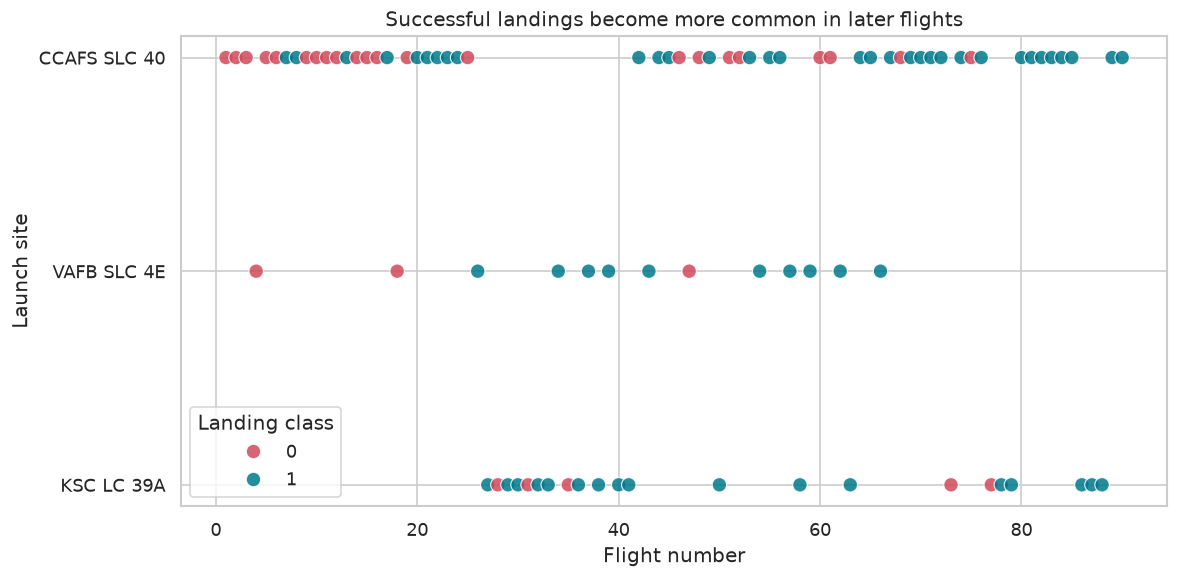

In [2]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=data, x="FlightNumber", y="LaunchSite", hue="Class",
    palette=palette, s=75, alpha=0.85
)
plt.title("Successful landings become more common in later flights")
plt.xlabel("Flight number")
plt.ylabel("Launch site")
plt.legend(title="Landing class")
plt.tight_layout()
plt.show()

### Payload mass versus launch site

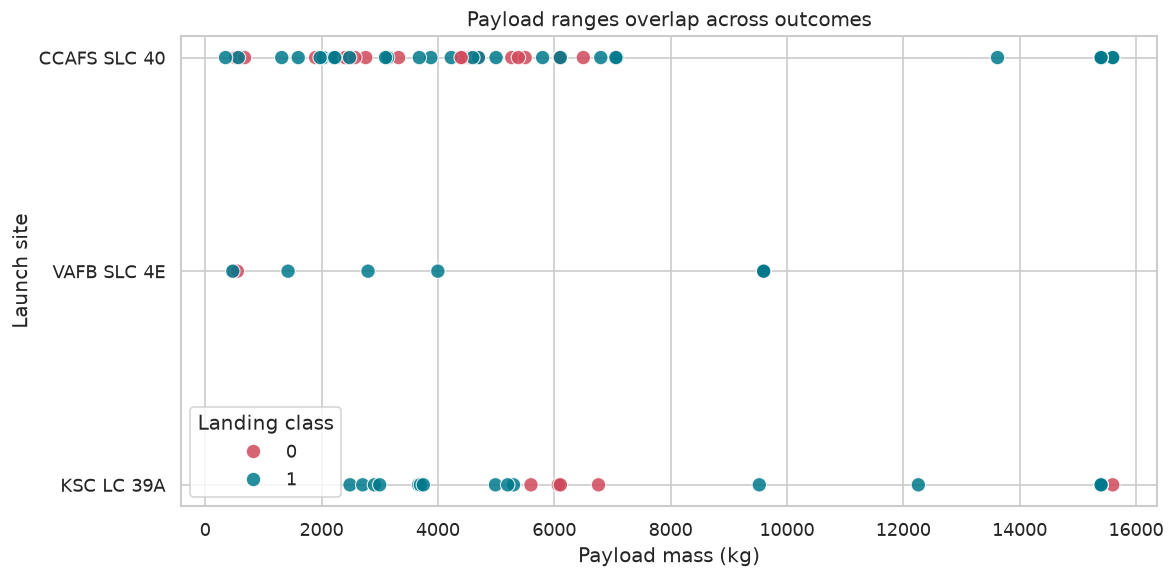

In [3]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=data, x="PayloadMass", y="LaunchSite", hue="Class",
    palette=palette, s=75, alpha=0.85
)
plt.title("Payload ranges overlap across outcomes")
plt.xlabel("Payload mass (kg)")
plt.ylabel("Launch site")
plt.legend(title="Landing class")
plt.tight_layout()
plt.show()

### Flight number versus orbit

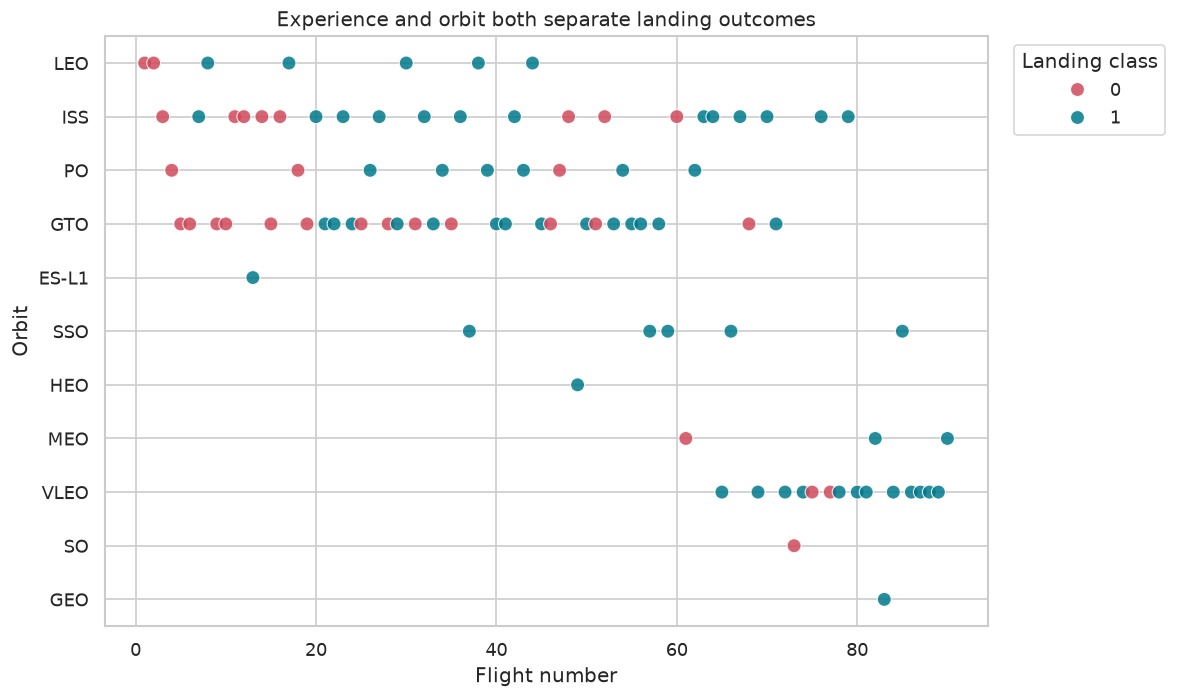

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data, x="FlightNumber", y="Orbit", hue="Class",
    palette=palette, s=70, alpha=0.85
)
plt.title("Experience and orbit both separate landing outcomes")
plt.xlabel("Flight number")
plt.ylabel("Orbit")
plt.legend(title="Landing class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Payload mass versus orbit

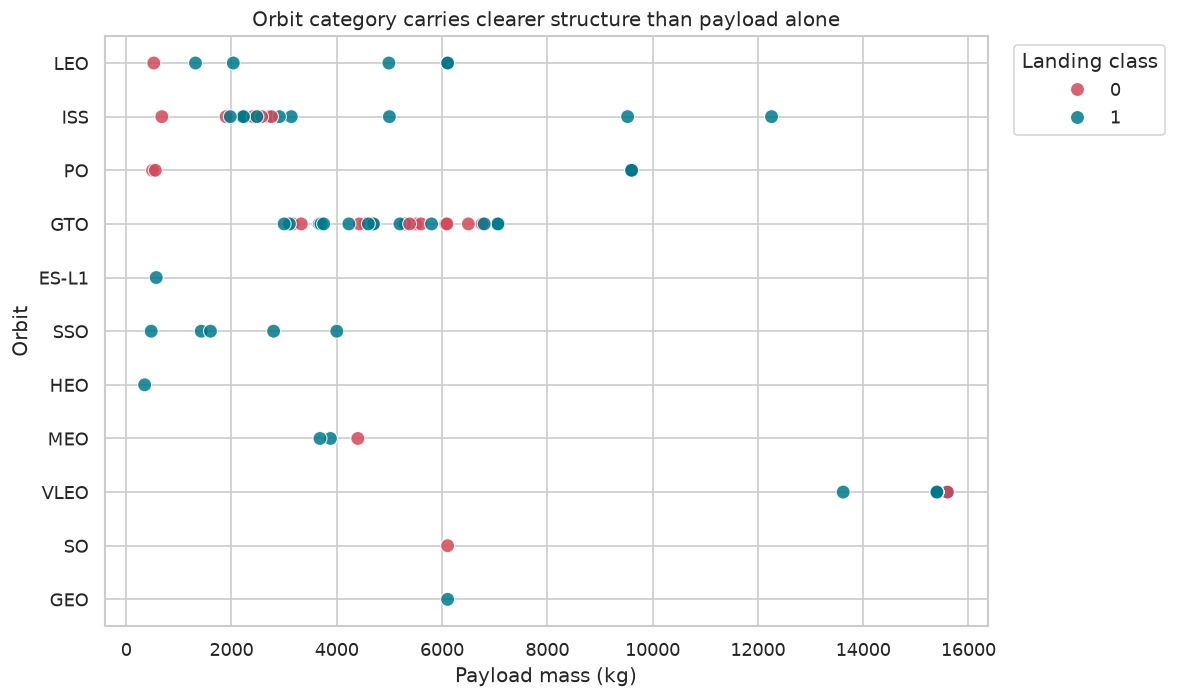

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data, x="PayloadMass", y="Orbit", hue="Class",
    palette=palette, s=70, alpha=0.85
)
plt.title("Orbit category carries clearer structure than payload alone")
plt.xlabel("Payload mass (kg)")
plt.ylabel("Orbit")
plt.legend(title="Landing class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Success rate by orbit

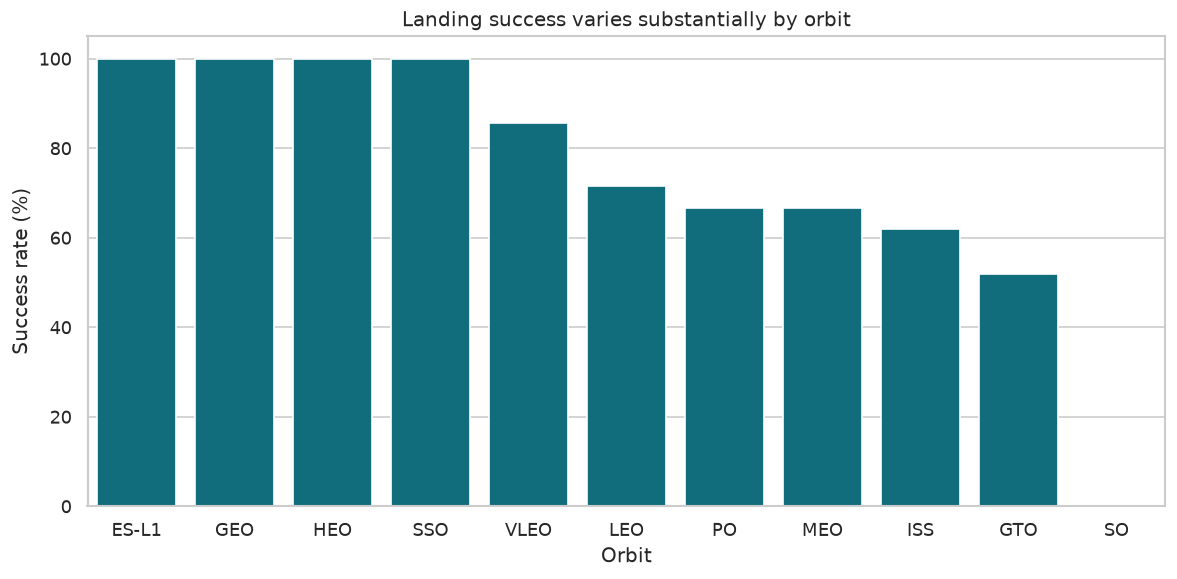

,launches,success_rate
Orbit,,
ES-L1,1,100.000
GEO,1,100.000
HEO,1,100.000
SSO,5,100.000
VLEO,14,85.714
LEO,7,71.429
PO,9,66.667
MEO,3,66.667
ISS,21,61.905


In [6]:
orbit_rate = (
    data.groupby("Orbit")["Class"].agg(launches="size", success_rate="mean")
    .assign(success_rate=lambda x: 100 * x["success_rate"])
    .sort_values("success_rate", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=orbit_rate.reset_index(), x="Orbit", y="success_rate", color="#00798c"
)
plt.ylim(0, 105)
plt.title("Landing success varies substantially by orbit")
plt.xlabel("Orbit")
plt.ylabel("Success rate (%)")
plt.tight_layout()
plt.show()
orbit_rate.round(3)

### Average success rate by year

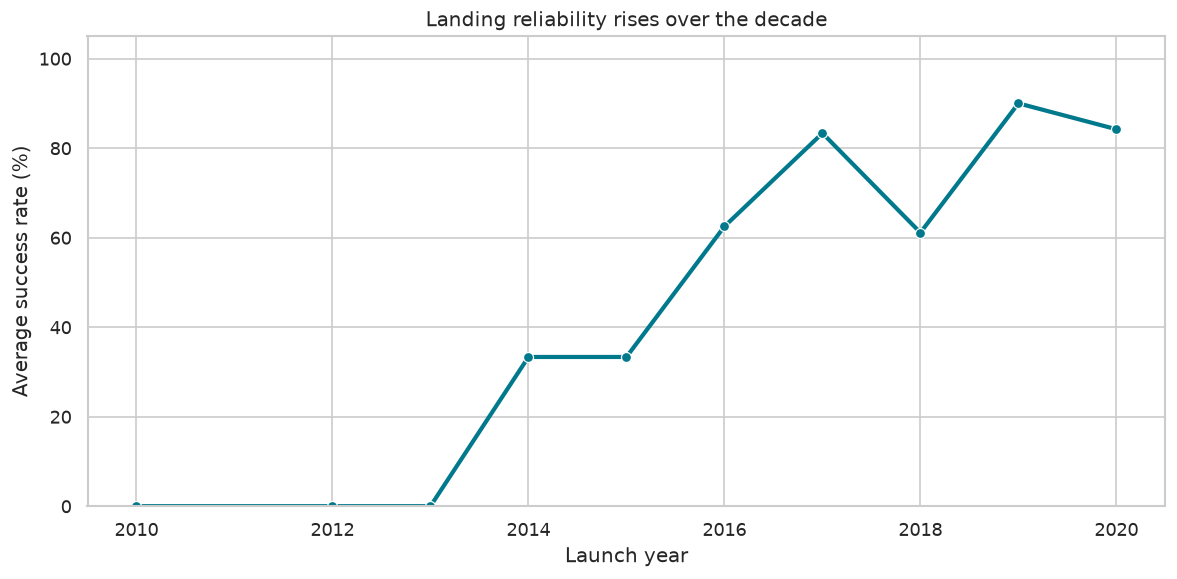

,launches,success_rate
Year,,
2010,1,0.000
2012,1,0.000
2013,3,0.000
2014,6,33.333
2015,6,33.333
2016,8,62.500
2017,18,83.333
2018,18,61.111
2019,10,90.000


In [7]:
yearly_rate = (
    data.groupby("Year")["Class"].agg(launches="size", success_rate="mean")
    .assign(success_rate=lambda x: 100 * x["success_rate"])
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=yearly_rate.reset_index(), x="Year", y="success_rate",
    marker="o", linewidth=2.5, color="#00798c"
)
plt.ylim(0, 105)
plt.title("Landing reliability rises over the decade")
plt.xlabel("Launch year")
plt.ylabel("Average success rate (%)")
plt.tight_layout()
plt.show()
yearly_rate.round(3)

In [8]:
site_rate = (
    data.groupby("LaunchSite")["Class"]
    .agg(launches="size", successes="sum", success_rate="mean")
    .assign(success_rate=lambda x: (100 * x["success_rate"]).round(1))
)
site_rate

,launches,successes,success_rate
LaunchSite,,,
CCAFS SLC 40,55,33,60.0
KSC LC 39A,22,17,77.3
VAFB SLC 4E,13,10,76.9


### Interpretation

Later flights contain more successful outcomes, and annual success rises from 0% in the
earliest years to 90% in 2019 and 84.2% in 2020. KSC LC 39A and VAFB SLC 4E each reach
approximately 77% success. Payload distributions overlap, so payload should not be treated
as a stand-alone decision rule.